# 3.0 Arquitectura del LLM

## 3.1 Codificando la arquitectura del LLM

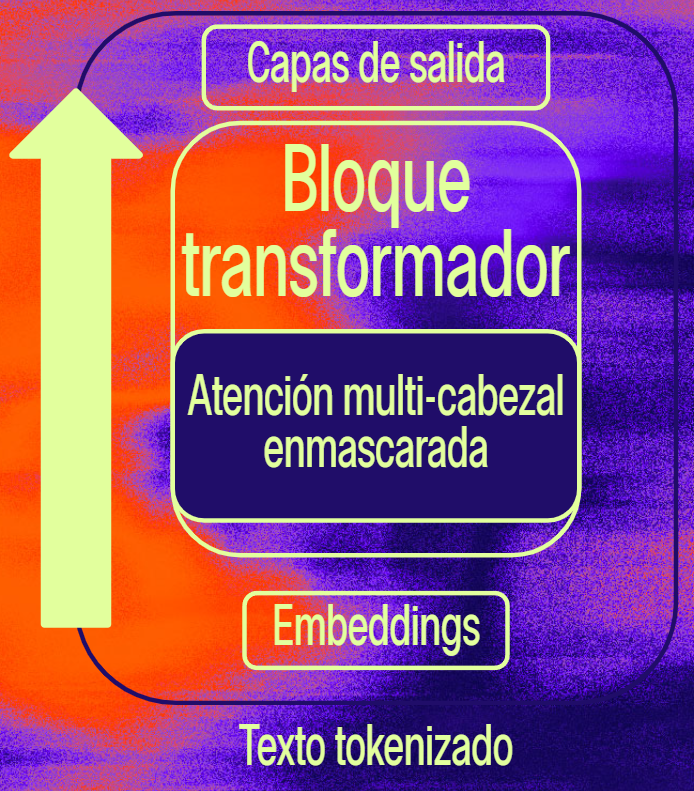

In [1]:
cfg = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads (para la atención multi-cabezal enmascarada)
    "n_layers": 12,         # Number of layers (iteraciones en el bloque transformador)
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [2]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()

    def forward(self,x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self,x):
        return x

In [3]:
#!uv pip install transformers

In [4]:
import torch
from transformers import AutoTokenizer

model_name = "dccuchile/bert-base-spanish-wwm-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

batch = []
txt1 = "La puerta se"
txt2 = "Yo sé quién"

#Al usar return_tensors="pt" ya me da un tensor, no hace falta torch.tensor
#El input_ids[0] para recoger los tokens del objeto devuelto por el tokenizer
#El [:-1] para quitar el token de final de frase [SEP].
#El token final de "separación" ([SEP]) le estorba, porque el modelo intentaría predecir qué sigue 
#después del final de la frase, en lugar de completar la frase misma.
batch.append(tokenizer(txt1, return_tensors="pt")["input_ids"][0][:-1])
batch.append(tokenizer(txt2, return_tensors="pt")["input_ids"][0][:-1])
#Apila el "tensor de tensores" en una matriz donde apila tensores uno debajo de otro
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[   4, 1032, 2936, 1057],
        [   4, 1252, 1486, 1704]])


In [5]:
batch.shape

torch.Size([2, 4])

In [6]:
torch.manual_seed(123)
model = DummyGPTModel(cfg=cfg)

#Al output de la última capa de la red se le llama logits
logits = model(batch)
print("Output shape:",logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1361, -0.7281, -0.2817,  ..., -0.5330,  1.1371,  0.8244],
         [ 0.3356,  0.8562, -0.0674,  ..., -0.8851,  0.0878,  0.9125],
         [ 1.6195,  0.5443,  1.0512,  ...,  0.2245,  0.7144, -0.4429],
         [-0.6312,  1.4045, -1.5814,  ...,  2.5904, -0.1709, -0.3281]],

        [[ 0.3177, -0.8315, -0.0821,  ..., -0.6782,  0.7889,  0.8382],
         [ 0.1167,  0.3861, -1.1812,  ..., -0.2059,  0.1657,  0.5307],
         [-0.3184,  1.7393,  1.0251,  ...,  0.9451,  0.2395, -1.3694],
         [ 2.2212, -0.3139, -0.5092,  ...,  2.8847, -0.9422, -1.0191]]],
       grad_fn=<UnsafeViewBackward0>)


## 3.2 Normalización de capas

In [7]:
torch.manual_seed(123)

batch_example = torch.randn(2,1000)
batch_example

tensor([[ 0.3374, -0.1778, -0.3035,  ..., -1.5753, -0.6813, -0.4181],
        [ 0.2573,  0.6937,  0.4207,  ..., -0.3439,  0.0665, -0.1417]])

La normalización de capas consiste en el método por el cuál optimizamos el output de cada neurona para satisfacer el reajuste de los pesos sin tener problemas de gradiente. Esto se consigue estableciendo un rango para los pesos obtenidos por una capa para que la media esté en 0 y la varianza en 1, significando que todos los valores estarán en el mismo rango y éste rango estará centrado. De esta forma las funciones de activación serán lo más efectivas posibles y no habrá problemas con el gradiente al pasar los pesos de capa a capa.

In [8]:
layer = nn.Sequential(nn.Linear(1000,1000),nn.ReLU())
out = layer(batch_example)
out

tensor([[0.0000, 0.9387, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.3703,  ..., 0.0000, 0.3784, 1.3145]],
       grad_fn=<ReluBackward0>)

In [9]:
#Media entre filas
mean = out.mean(dim=1, keepdim=True)

In [10]:
var = out.var(dim=1, keepdim=True)
var

tensor([[0.1026],
        [0.1203]], grad_fn=<VarBackward0>)

In [11]:
normed = ((out - mean) / torch.sqrt(var))
normed.var(dim=1,keepdim=True)


tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)

In [12]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        #self.eps es para que el número nunca sea dividido entre 0
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        #Durante el aprendizaje el modelo puede hacer undo sobre x-mean sumando self.shit cuando aprenda que es lo más óptimo.
        #Ajustará de ese modo la normalización en función de su entrenamiento, por eso al principio son 0s, porque el modelo irá desarrollando
        #conforme aumenten las épocas y al principio no regulará.
        #Lo mismo pasará con self.scale,al principio multiplicará los pesos normalizados por 1 (se quedará igual) pero conforme vaya aprendiendo
        #ajustará la división / torch.sqrt(var + self.eps) con la multiplicación de self.scale.
        return self.scale * norm_x + self.shift

In [13]:
ln = LayerNorm(1000)
outputs_normed = ln(out)

In [14]:
outputs_normed

tensor([[-0.7057,  2.2263, -0.7057,  ..., -0.7057, -0.7057, -0.7057],
        [-0.6934, -0.6934,  0.3746,  ..., -0.6934,  0.3980,  3.0976]],
       grad_fn=<AddBackward0>)

In [15]:
outputs_normed.mean(dim=1,keepdim=True)

tensor([[-8.1062e-09],
        [-5.7220e-09]], grad_fn=<MeanBackward1>)

In [16]:
outputs_normed.var(dim=1,keepdim=True)

tensor([[1.0009],
        [1.0009]], grad_fn=<VarBackward0>)

## 3.3 Implementación de una red de alimentación hacia adelante con activaciones GELU

A la hora de clasificar la información extraída de los inputs nuestro modelo requiere de funciones de activación no lineales para hacer clusters de forma óptima.

Utilizaremos la función GELU entre las capas neuronales ocultas.

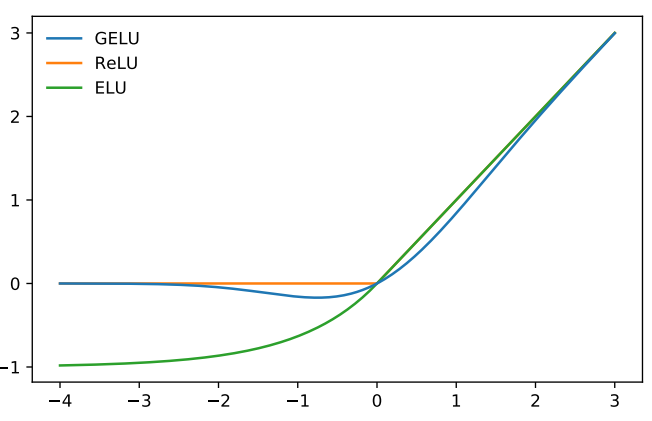

Según el paper "Gaussian Error Linear Units (GELUs)" la función que nos sugiere es mejor que ELU o incluso ReLU.

ReLU hace que si los inputs son negativos el output será 0, mientras que si son postivos corresponderán a su propio valor.

GELU es similar, pero exhibe curvatura en todos sus puntos, lo que le permite aproximar funciones matemáticas complejas con mayor facilidad que las activaciones lineales por partes. Además, esta función pondera las entradas por su magnitud en lugar de simplemente filtrarlas por su signo (como hace la ReLU).

Se puede aproximar con esta fórmula por términos de eficiencia.

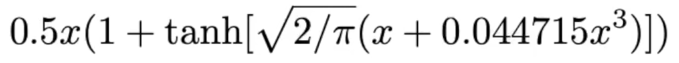

In [17]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (1+torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi)) *
            (x + 0.044715 * torch.pow(x,3))
        ))


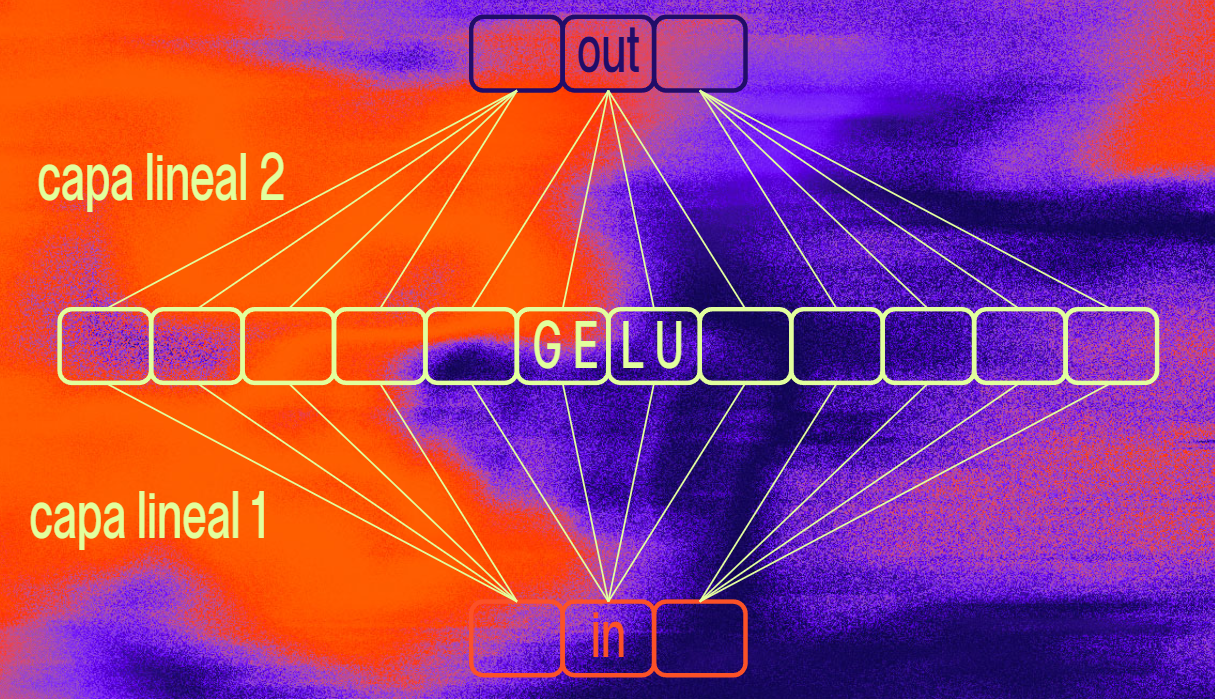

In [18]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            #El hiperparámetro 4 es 4 debido a que simulamos la arquitectura GPT pero podría ser cualquiera
            #ya que al final nos quedará la dimensión de los embed
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
            return self.layers(x)

In [19]:
ffn = FeedForward(cfg)

In [20]:
x = torch.rand(2,3,768)
ffn(x).shape

torch.Size([2, 3, 768])

## 3.4 Adición de las shortcut connections

En el paper "Deep Residual Learning for Image Recognition", se nos presenta una imagen que nos relata qué son estas conexiones.

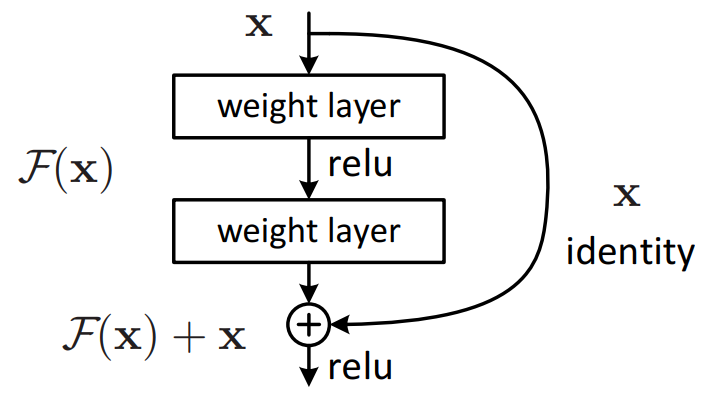

Tenemos los outputs de la función GELU (en nuestro caso) y le sumaremos los pesos iniciales F(x) + x.

Si la red no aprende nada útil en alguna iteración o hay un error de gradiente ésta rescatará los pesos anteriores mediante estas shortcut connections. Ayuda a ignorar capas que son contraproducentes.

La técnica de configuración de gradiente utilizada se denomina "Backpropagation" la cuál asignará los gradientes comenzando desde la última capa hacia atrás, llegando finalmente a la primera. 

Conforme la asignación de gradiente se va acercando a la primera capa, este gradiente va siendo más débil hasta llegar a cifras demasiado pequeñas casi insignificantes, dificultando así el aprendizaje.

Al añadir las shortcut connections, añadiremos a la salida de las funciones GELU los pesos sobre los que ha operado, y así tendremos más información para aumentar el tamaño de los gradientes asignados.

In [21]:
import torch
import torch.nn as nn

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), nn.GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            #Si los pesos previos tienen la misma dimensión se aplica el shortcut
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    #Calcula el error
    loss = nn.MSELoss()
    loss = loss(output, target)

    #Propagación hacia atrás para calcular los gradientes
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            #Printea la media en valores absolutos de los gradientes de los pesos
            print(f"{name} tiene una media de gradiente de {param.grad.abs().mean().item()}")
    

In [22]:
layer_sizes = [3,3,3,3,3,1]

In [23]:
sample_input = torch.tensor([[1., 0., -1.]])

In [24]:
torch.manual_seed(123)
modelo_sin_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(modelo_sin_shortcut,sample_input)

layers.0.0.weight tiene una media de gradiente de 0.0002017411752603948
layers.1.0.weight tiene una media de gradiente de 0.00012011770741082728
layers.2.0.weight tiene una media de gradiente de 0.0007152437465265393
layers.3.0.weight tiene una media de gradiente de 0.0013988513965159655
layers.4.0.weight tiene una media de gradiente de 0.005049604922533035


In [25]:
torch.manual_seed(123)
modelo_sin_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(modelo_sin_shortcut,sample_input)

layers.0.0.weight tiene una media de gradiente de 0.22186796367168427
layers.1.0.weight tiene una media de gradiente de 0.207092747092247
layers.2.0.weight tiene una media de gradiente de 0.32923877239227295
layers.3.0.weight tiene una media de gradiente de 0.2667771875858307
layers.4.0.weight tiene una media de gradiente de 1.3268063068389893


## 3.5 Conectando las capas de atención y lineales en un bloque Transformer

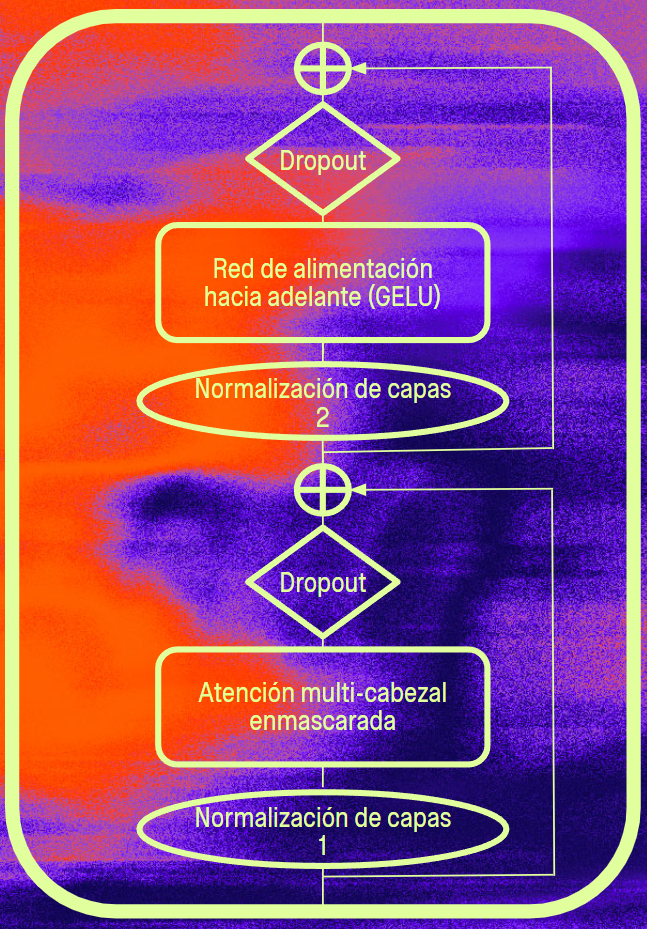

In [26]:
from clases_a_utilizar import MultiHeadAttention

class TransformerBlock(nn.Module):
    
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        #Primera fase
        shortcut = x
        x = self.norm1(x)
        x = self.att(x) #[batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut #Sumamos los logits al input anterior
    
        #Segunda fase
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut #Sumamos los logits al input anterior
    
        return x

In [27]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)
block = TransformerBlock(cfg)
output = block(x)

In [28]:
x.shape

torch.Size([2, 4, 768])

In [29]:
output.shape

torch.Size([2, 4, 768])

## 3.6 Codificando el modelo GPT

In [30]:
import torch
from transformers import AutoTokenizer

model_name = "dccuchile/bert-base-spanish-wwm-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

batch = []
txt1 = "La puerta se"
txt2 = "Yo sé quién"

#Al usar return_tensors="pt" ya me da un tensor, no hace falta torch.tensor
#El input_ids[0] para recoger los tokens del objeto devuelto por el tokenizer
#El [:-1] para quitar el token de final de frase [SEP].
#El token final de "separación" ([SEP]) le estorba, porque el modelo intentaría predecir qué sigue 
#después del final de la frase, en lugar de completar la frase misma.
batch.append(tokenizer(txt1, return_tensors="pt")["input_ids"][0][:-1])
batch.append(tokenizer(txt2, return_tensors="pt")["input_ids"][0][:-1])
#Apila el "tensor de tensores" en una matriz donde apila tensores uno debajo de otro
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[   4, 1032, 2936, 1057],
        [   4, 1252, 1486, 1704]])


In [31]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [32]:
torch.manual_seed(123)

model = GPTModel(cfg)
out = model(batch)

In [33]:
batch.shape

torch.Size([2, 4])

In [34]:
out.shape

torch.Size([2, 4, 50257])

In [35]:
total_params = sum(p.numel() for p in model.parameters())
#Hay parámetros redundantes al redimensionar al principio y al final, por lo que restamos los del final
total_params = total_params - model.out_head.weight.numel()

In [36]:
#Tiene 124M de parámetros
total_params

124412160

En el paper original de GPT2 "Language Models are Unsupervised Multitask Learners" nos indica la arquitectura de hiperparámetros escogida en función del número de parámetros, hemos utilizado la primera para las capas y los embeddings. El número de parámetros está equivocado en la tabla del paper, debería ser 124M.

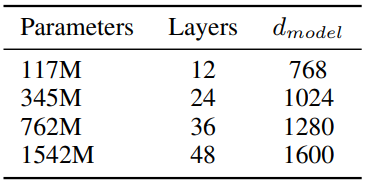

## 3.7 Generando texto

Los LLM generan texto por iteraciones, y en cada una de ellas se genera un token para concatenarse en la siguiente como un input. Los tokens son parseados a texto.

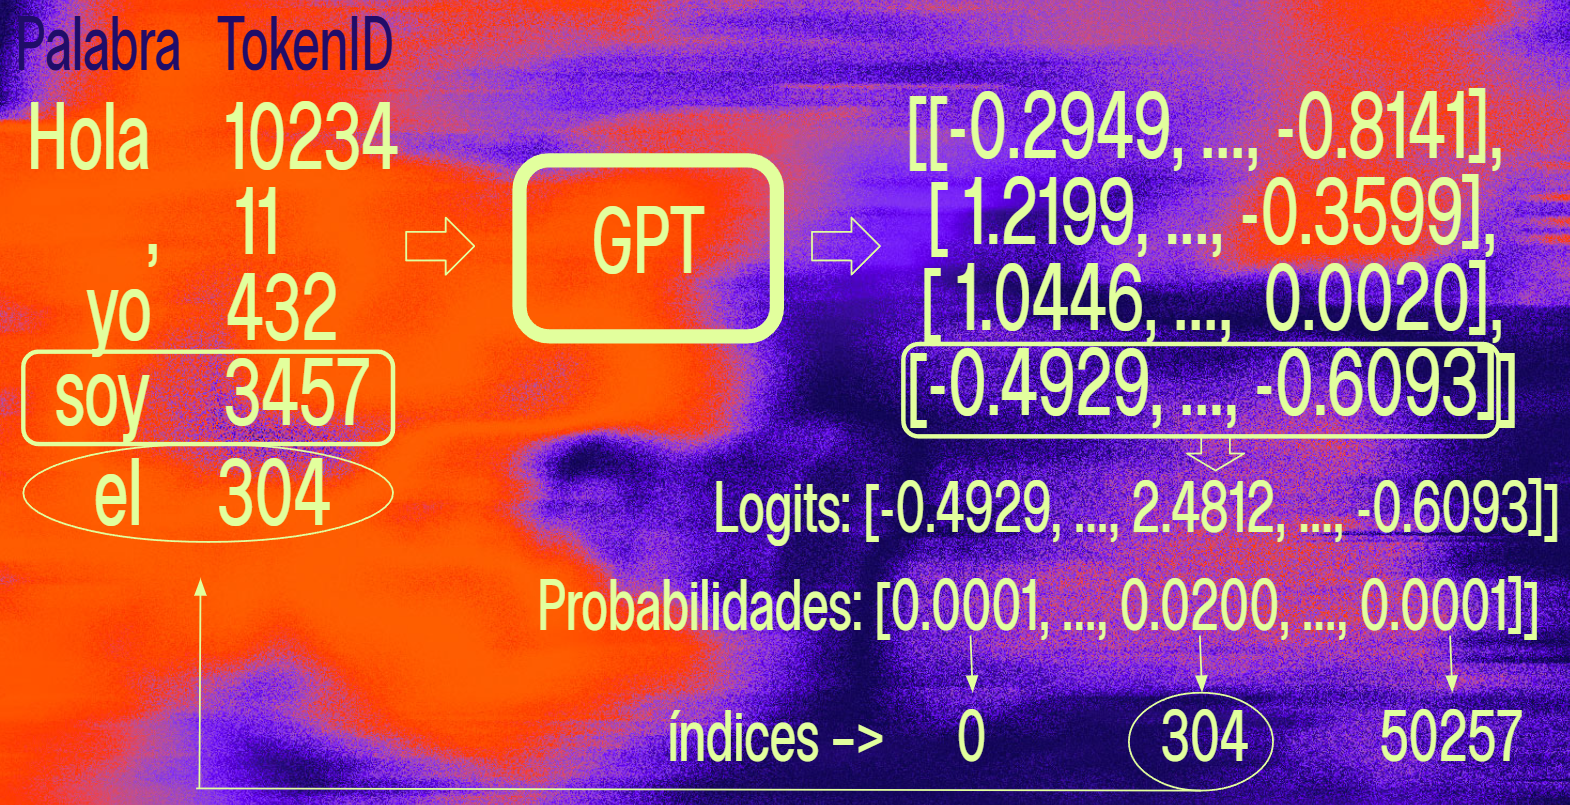

In [37]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        probas = torch.softmax(logits,dim=-1)

        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [38]:
start_context = "Hola, yo soy"
encoded_tensor = tokenizer(start_context, return_tensors="pt")["input_ids"][0][1:-1].unsqueeze(0)
encoded_tensor.shape

torch.Size([1, 4])

In [39]:
encoded_tensor

tensor([[1734, 1019, 1252, 1581]])

In [40]:
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=cfg["context_length"]
)

In [41]:
out

tensor([[ 1734,  1019,  1252,  1581, 10672, 49856, 30793, 42877, 47881, 41259]])

In [42]:
tokenizer.batch_decode(out)

['hola, yo soyídate burdeos']